[tanh] Epoch 200/1000, Loss = 0.970762
[tanh] Epoch 400/1000, Loss = 0.820757
[tanh] Epoch 600/1000, Loss = 0.808979
[tanh] Epoch 800/1000, Loss = 0.790975
[tanh] Epoch 1000/1000, Loss = 0.761796
[relu] Epoch 200/1000, Loss = 0.769797
[relu] Epoch 400/1000, Loss = 0.693117
[relu] Epoch 600/1000, Loss = 0.596969
[relu] Epoch 800/1000, Loss = 0.452009
[relu] Epoch 1000/1000, Loss = 0.291144


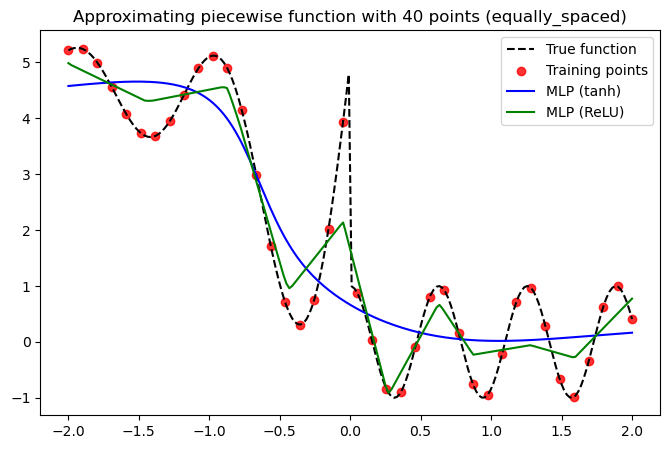

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# HOMEWORK 3 #
# Problem #1 #

# ------------------
# 1. Define the piecewise function
# ------------------
def piecewise_function(x):
    """
    y = 5 + sum_{k=1 to 6} sin(kx)    if x < 0
        cos(10x)                     if x >= 0
    """
    if x < 0:
        return 5.0 + sum(np.sin(k * x) for k in range(1, 7))
    else:
        return np.cos(10 * x)

# ------------------
# 2. Generate data
# ------------------

def generate_data(n_points=40, mode='equally_spaced', x_min=-2.0, x_max=2.0, seed=0):
    """
    Generate n_points samples of (x, y).
    mode: 'equally_spaced' or 'random_uniform'
    """
    np.random.seed(seed)
    if mode == 'equally_spaced':
        xs = np.linspace(x_min, x_max, n_points)
    else:  # random_uniform
        xs = np.random.uniform(low=x_min, high=x_max, size=n_points)

    ys = np.array([piecewise_function(x) for x in xs])
    return xs, ys

# ------------------
# 3. Define a simple MLP
# ------------------

class Net(nn.Module):
    def __init__(self, hidden_size=32, activation='tanh'):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(1, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)

        if activation == 'tanh':
            self.act = nn.Tanh()
        elif activation == 'relu':
            self.act = nn.ReLU()
        else:
            raise ValueError("Choose 'tanh' or 'relu' for activation.")

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.fc3(x)
        return x

# ------------------
# 4. Training routine
# ------------------
def train_model(xs, ys, activation='tanh', n_epochs=1000, lr=1e-3):
    # Convert to torch tensors
    xs_torch = torch.tensor(xs, dtype=torch.float).view(-1, 1)
    ys_torch = torch.tensor(ys, dtype=torch.float).view(-1, 1)

    net = Net(hidden_size=32, activation=activation)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(n_epochs):
        optimizer.zero_grad()
        outputs = net(xs_torch)
        loss = loss_fn(outputs, ys_torch)
        loss.backward()
        optimizer.step()

        if (epoch+1) % 200 == 0:
            print(f"[{activation}] Epoch {epoch+1}/{n_epochs}, Loss = {loss.item():.6f}")

    return net

# ------------------
# 5. Putting it all together
# ------------------

if __name__ == "__main__":
    # Choose number of points and sampling strategy
    n_points = 40  # or 80
    mode = 'equally_spaced'  # or 'random_uniform'
    x_train, y_train = generate_data(n_points=n_points, mode=mode)

    # Train two models: one with tanh, one with ReLU
    net_tanh = train_model(x_train, y_train, activation='tanh', n_epochs=1000)
    net_relu = train_model(x_train, y_train, activation='relu', n_epochs=1000)

    # Evaluate models on a finer grid for visualization
    x_eval = np.linspace(-2, 2, 200)
    y_true = [piecewise_function(x) for x in x_eval]

    # Convert to torch and predict
    x_eval_torch = torch.tensor(x_eval, dtype=torch.float).view(-1, 1)
    y_pred_tanh = net_tanh(x_eval_torch).detach().numpy().flatten()
    y_pred_relu = net_relu(x_eval_torch).detach().numpy().flatten()

    # Plot results
    plt.figure(figsize=(8,5))
    plt.plot(x_eval, y_true, 'k--', label='True function')
    plt.scatter(x_train, y_train, color='red', alpha=0.8, label='Training points')
    plt.plot(x_eval, y_pred_tanh, label='MLP (tanh)', color='blue')
    plt.plot(x_eval, y_pred_relu, label='MLP (ReLU)', color='green')
    plt.legend()
    plt.title(f"Approximating piecewise function with {n_points} points ({mode})")
    plt.show()


In [5]:
import jax.numpy as jnp
from jax import grad, jit

# Problem #1 #
# Decided to change to JAX since its better at handling higher order derivatives #

# Define the Laplacian function using JAX
def laplacian_3d_jax(func):
    """
    Creates a function that computes the Laplacian of a 3D function using JAX.

    Args:
        func: Function that takes (x,y,z) and returns a scalar

    Returns:
        A function that computes the Laplacian of func at given points
    """
    # Compute second derivatives with respect to each variable
    grad_x = grad(func, argnums=0)
    grad_y = grad(func, argnums=1)
    grad_z = grad(func, argnums=2)

    # Compute Laplacian as sum of second derivatives
    grad_xx = grad(grad_x, argnums=0)
    grad_yy = grad(grad_y, argnums=1)
    grad_zz = grad(grad_z, argnums=2)

    # Return a function that computes the Laplacian
    def laplacian(x, y, z):
        return grad_xx(x, y, z) + grad_yy(x, y, z) + grad_zz(x, y, z)

    return jit(laplacian)  # JIT-compile for speed

# Test the Laplacian on the example functions
def test_laplacian_jax():
    # Test point
    x, y, z = 2.0, 3.0, 4.0

    # Example (a): f(x,y,z) = sqrt(xy) + z
    def f_a(x, y, z):
        return jnp.sqrt(x * y) + z

    # Example (b): f(x,y,z) = sqrt(3x² + y² + 5z²)
    def f_b(x, y, z):
        return jnp.sqrt(3 * x**2 + y**2 + 5 * z**2)

    # Example (c): f(x,y,z) = x⁷y⁵
    def f_c(x, y, z):
        return x**7 * y**5

    # Example (d): f(x,y,z) = 1/sqrt(x²+y²+z²)
    def f_d(x, y, z):
        return 1 / jnp.sqrt(x**2 + y**2 + z**2)

    # Compute the Laplacians using JAX
    lap_a = laplacian_3d_jax(f_a)(x, y, z)
    lap_b = laplacian_3d_jax(f_b)(x, y, z)
    lap_c = laplacian_3d_jax(f_c)(x, y, z)
    lap_d = laplacian_3d_jax(f_d)(x, y, z)

    print(f"Test point: x = {x}, y = {y}, z = {z}")

    print("\nExample (a): f(x,y,z) = sqrt(xy) + z")
    print(f"Laplacian = {lap_a}")

    print("\nExample (b): f(x,y,z) = sqrt(3x² + y² + 5z²)")
    print(f"Laplacian = {lap_b}")

    print("\nExample (c): f(x,y,z) = x⁷y⁵")
    print(f"Laplacian = {lap_c}")

    print("\nExample (d): f(x,y,z) = 1/sqrt(x²+y²+z²)")
    print(f"Laplacian = {lap_d}")

    # Analytical solution for example (c): ∇²f = 42x⁵y⁵ + 20x⁷y³
    analytical_c = 42 * (x**5) * (y**5) + 20 * (x**7) * (y**3)
    print(f"\nAnalytical solution for example (c): {analytical_c}")
    print(f"Difference: {abs(lap_c - analytical_c)}")

if __name__ == "__main__":
    test_laplacian_jax()

Test point: x = 2.0, y = 3.0, z = 4.0

Example (a): f(x,y,z) = sqrt(xy) + z
Laplacian = -0.2211344689130783

Example (b): f(x,y,z) = sqrt(3x² + y² + 5z²)
Laplacian = 0.4571259915828705

Example (c): f(x,y,z) = x⁷y⁵
Laplacian = 395712.0

Example (d): f(x,y,z) = 1/sqrt(x²+y²+z²)
Laplacian = -1.3969838619232178e-09

Analytical solution for example (c): 395712.0
Difference: 0.0


Part 3: Shallow Network with 200 data points

Training shallow network with width 10 and 200 data points
Run 1, Width 10, Epoch 1000, Loss: 0.861983
Run 1, Width 10, Epoch 2000, Loss: 0.677627
Run 1, Width 10, Epoch 3000, Loss: 0.591970
Run 1, Width 10, Epoch 4000, Loss: 0.562888
Run 1, Width 10, Epoch 5000, Loss: 0.548779
Run 2, Width 10, Epoch 1000, Loss: 0.766069
Run 2, Width 10, Epoch 2000, Loss: 0.650453
Run 2, Width 10, Epoch 3000, Loss: 0.569638
Run 2, Width 10, Epoch 4000, Loss: 0.532557
Run 2, Width 10, Epoch 5000, Loss: 0.513960
Run 3, Width 10, Epoch 1000, Loss: 0.738497
Run 3, Width 10, Epoch 2000, Loss: 0.678050
Run 3, Width 10, Epoch 3000, Loss: 0.633862
Run 3, Width 10, Epoch 4000, Loss: 0.610063
Run 3, Width 10, Epoch 5000, Loss: 0.606316
Run 4, Width 10, Epoch 1000, Loss: 0.917280
Run 4, Width 10, Epoch 2000, Loss: 0.737059
Run 4, Width 10, Epoch 3000, Loss: 0.663491
Run 4, Width 10, Epoch 4000, Loss: 0.570868
Run 4, Width 10, Epoch 5000, Loss: 0.528460
Run 5, Width 10

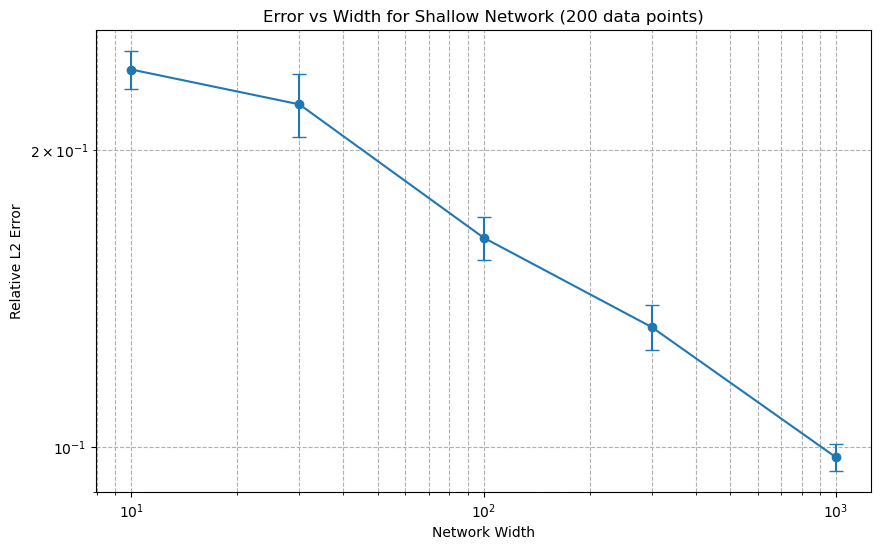


Part 3a: Deep Network (2 hidden layers) with 200 data points

Training deep network with width 10 and 200 data points
Run 1, Width 10, Epoch 1000, Loss: 0.510708
Run 1, Width 10, Epoch 2000, Loss: 0.448546
Run 1, Width 10, Epoch 3000, Loss: 0.404525
Run 1, Width 10, Epoch 4000, Loss: 0.308549
Run 1, Width 10, Epoch 5000, Loss: 0.251453
Run 2, Width 10, Epoch 1000, Loss: 0.582576
Run 2, Width 10, Epoch 2000, Loss: 0.522256
Run 2, Width 10, Epoch 3000, Loss: 0.484987
Run 2, Width 10, Epoch 4000, Loss: 0.472075
Run 2, Width 10, Epoch 5000, Loss: 0.463849
Run 3, Width 10, Epoch 1000, Loss: 0.541354
Run 3, Width 10, Epoch 2000, Loss: 0.398521
Run 3, Width 10, Epoch 3000, Loss: 0.321924
Run 3, Width 10, Epoch 4000, Loss: 0.302941
Run 3, Width 10, Epoch 5000, Loss: 0.290013
Run 4, Width 10, Epoch 1000, Loss: 0.625861
Run 4, Width 10, Epoch 2000, Loss: 0.563390
Run 4, Width 10, Epoch 3000, Loss: 0.533694
Run 4, Width 10, Epoch 4000, Loss: 0.512576
Run 4, Width 10, Epoch 5000, Loss: 0.499669
R

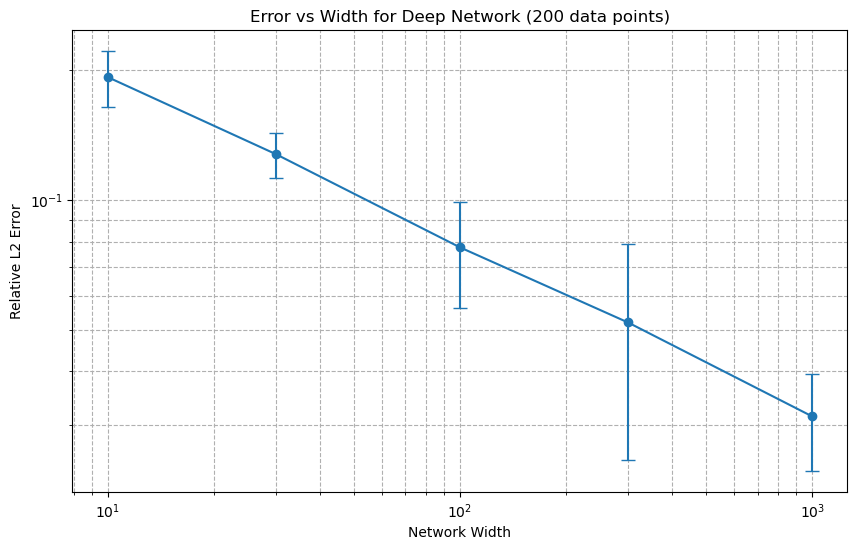


Part 3b: Shallow Network with 20 data points

Training shallow network with width 10 and 20 data points
Run 1, Width 10, Epoch 1000, Loss: 0.836979
Run 1, Width 10, Epoch 2000, Loss: 0.656500
Run 1, Width 10, Epoch 3000, Loss: 0.555473
Run 1, Width 10, Epoch 4000, Loss: 0.511459
Run 1, Width 10, Epoch 5000, Loss: 0.508017
Run 2, Width 10, Epoch 1000, Loss: 0.731709
Run 2, Width 10, Epoch 2000, Loss: 0.608572
Run 2, Width 10, Epoch 3000, Loss: 0.513125
Run 2, Width 10, Epoch 4000, Loss: 0.500536
Run 2, Width 10, Epoch 5000, Loss: 0.488166
Run 3, Width 10, Epoch 1000, Loss: 0.688446
Run 3, Width 10, Epoch 2000, Loss: 0.621897
Run 3, Width 10, Epoch 3000, Loss: 0.562121
Run 3, Width 10, Epoch 4000, Loss: 0.534142
Run 3, Width 10, Epoch 5000, Loss: 0.527341
Run 4, Width 10, Epoch 1000, Loss: 0.910323
Run 4, Width 10, Epoch 2000, Loss: 0.699275
Run 4, Width 10, Epoch 3000, Loss: 0.619821
Run 4, Width 10, Epoch 4000, Loss: 0.584685
Run 4, Width 10, Epoch 5000, Loss: 0.560717
Run 5, Width 10

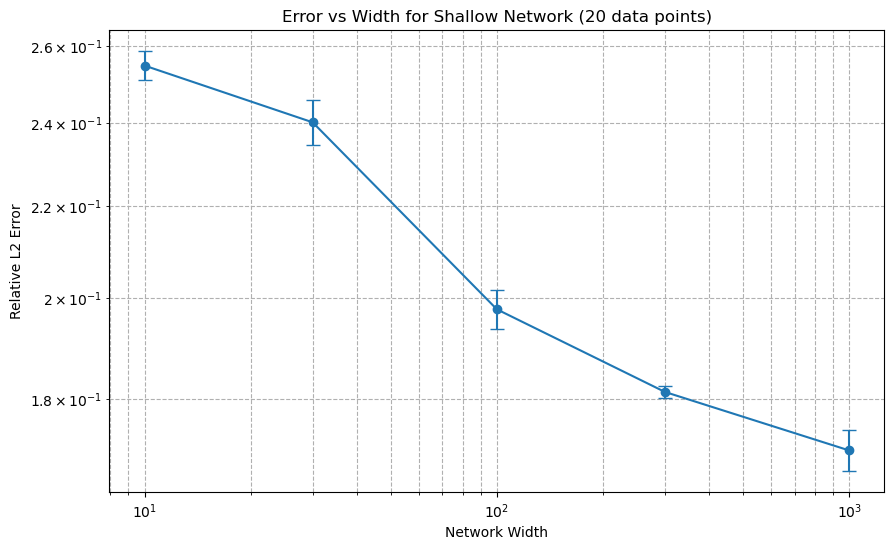

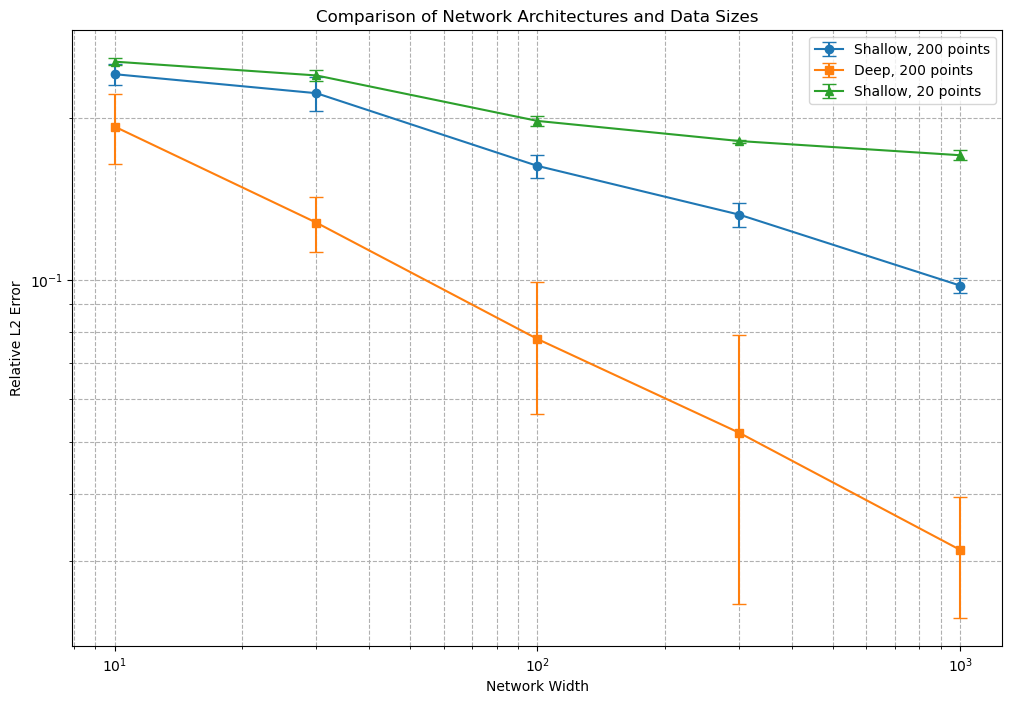

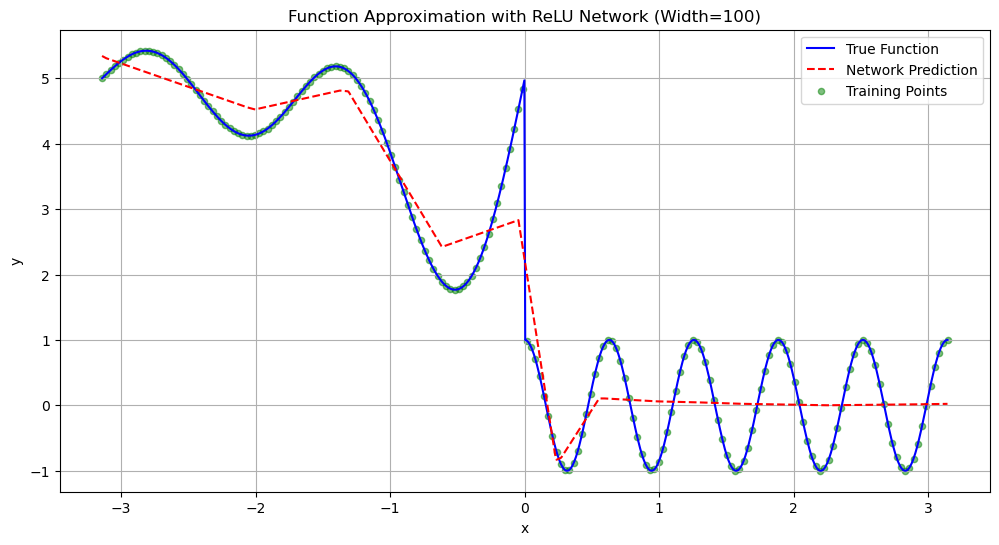

In [2]:
# Problem #3 #

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from time import time
import random

# Set seeds for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    
# Define the target oscillatory function
def target_function(x):
    result = torch.zeros_like(x)
    
    # Region x < 0
    mask_neg = x < 0
    x_neg = x[mask_neg]
    sum_neg = torch.zeros_like(x_neg)
    for k in range(1, 5):  # Note: Problem statement says k=1 to 4
        sum_neg += torch.sin(k * x_neg)
    result[mask_neg] = 5 + sum_neg
    
    # Region x >= 0
    mask_pos = x >= 0
    x_pos = x[mask_pos]
    result[mask_pos] = torch.cos(10 * x_pos)
    
    return result

# Define the shallow ReLU network
class ShallowReLUNetwork(nn.Module):
    def __init__(self, width):
        super(ShallowReLUNetwork, self).__init__()
        self.layer1 = nn.Linear(1, width)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(width, 1)
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x

# Define the two-layer (deep) ReLU network
class DeepReLUNetwork(nn.Module):
    def __init__(self, width):
        super(DeepReLUNetwork, self).__init__()
        self.layer1 = nn.Linear(1, width)
        self.activation1 = nn.ReLU()
        self.layer2 = nn.Linear(width, width)
        self.activation2 = nn.ReLU()
        self.layer3 = nn.Linear(width, 1)
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.activation1(x)
        x = self.layer2(x)
        x = self.activation2(x)
        x = self.layer3(x)
        return x

# Function to compute L2 relative error
def compute_relative_error(predictions, targets):
    numerator = torch.sqrt(torch.sum((predictions - targets) ** 2))
    denominator = torch.sqrt(torch.sum(targets ** 2))
    return (numerator / denominator).item()

# Function to train network and evaluate performance
def train_and_evaluate(model_type, width, num_data_points, num_runs=10, epochs=5000, lr=0.001):
    errors = []
    
    for run in range(num_runs):
        set_seed(run)  # Different seed for each run
        
        # Generate training data
        x_train = torch.linspace(-np.pi, np.pi, num_data_points).reshape(-1, 1)
        if model_type == "random":
            x_train = (2 * torch.rand(num_data_points, 1) - 1) * np.pi  # Random in [-pi, pi]
        y_train = target_function(x_train)
        
        # Create model based on width
        if model_type == "deep":
            model = DeepReLUNetwork(width)
        else:
            model = ShallowReLUNetwork(width)
            
        # Set up optimizer
        optimizer = optim.Adam(model.parameters(), lr=lr)
        criterion = nn.MSELoss()
        
        # Training loop
        for epoch in range(epochs):
            optimizer.zero_grad()
            outputs = model(x_train)
            loss = criterion(outputs, y_train)
            loss.backward()
            optimizer.step()
            
            # Print progress occasionally
            if (epoch + 1) % 1000 == 0:
                print(f'Run {run+1}, Width {width}, Epoch {epoch+1}, Loss: {loss.item():.6f}')
        
        # Generate testing data (500 equi-spaced points)
        x_test = torch.linspace(-np.pi, np.pi, 500).reshape(-1, 1)
        y_test = target_function(x_test)
        
        # Evaluate model
        model.eval()
        with torch.no_grad():
            y_pred = model(x_test)
            rel_error = compute_relative_error(y_pred, y_test)
            errors.append(rel_error)
        
    # Calculate statistics
    mean_error = np.mean(errors)
    std_error = np.std(errors)
    
    return mean_error, std_error, errors

# Function to run experiments and plot results
def run_experiment(model_type="shallow", num_data_points=200):
    widths = [10, 30, 100, 300, 1000]
    mean_errors = []
    std_errors = []
    
    start_time = time()
    
    for width in widths:
        print(f"\nTraining {model_type} network with width {width} and {num_data_points} data points")
        mean_error, std_error, _ = train_and_evaluate(model_type, width, num_data_points)
        mean_errors.append(mean_error)
        std_errors.append(std_error)
        print(f"Width {width}: Mean Error = {mean_error:.6f}, Std Error = {std_error:.6f}")
    
    end_time = time()
    print(f"Total time: {end_time - start_time:.2f} seconds")
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.errorbar(widths, mean_errors, yerr=std_errors, fmt='o-', capsize=5)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Network Width')
    plt.ylabel('Relative L2 Error')
    plt.title(f'Error vs Width for {model_type.capitalize()} Network ({num_data_points} data points)')
    plt.grid(True, which="both", ls="--")
    plt.savefig(f'{model_type}_width_error_{num_data_points}.png')
    plt.show()
    
    return widths, mean_errors, std_errors

# Run the main experiments
if __name__ == "__main__":
    print("Part 3: Shallow Network with 200 data points")
    widths1, means1, stds1 = run_experiment("shallow", 200)
    
    print("\nPart 3a: Deep Network (2 hidden layers) with 200 data points")
    widths2, means2, stds2 = run_experiment("deep", 200)
    
    print("\nPart 3b: Shallow Network with 20 data points")
    widths3, means3, stds3 = run_experiment("shallow", 20)
    
    # Comparison plot
    plt.figure(figsize=(12, 8))
    plt.errorbar(widths1, means1, yerr=stds1, fmt='o-', capsize=5, label='Shallow, 200 points')
    plt.errorbar(widths2, means2, yerr=stds2, fmt='s-', capsize=5, label='Deep, 200 points')
    plt.errorbar(widths3, means3, yerr=stds3, fmt='^-', capsize=5, label='Shallow, 20 points')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Network Width')
    plt.ylabel('Relative L2 Error')
    plt.title('Comparison of Network Architectures and Data Sizes')
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.savefig('comparison_plot.png')
    plt.show()
    
    # Visualization of function and network prediction (for the last run)
    width = 100  # Choose a width for visualization
    model = ShallowReLUNetwork(width)
    x_train = torch.linspace(-np.pi, np.pi, 200).reshape(-1, 1)
    y_train = target_function(x_train)
    
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    # Quick training for visualization
    for epoch in range(3000):
        optimizer.zero_grad()
        outputs = model(x_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
    
    # Generate fine grid for smooth visualization
    x_vis = torch.linspace(-np.pi, np.pi, 1000).reshape(-1, 1)
    y_vis = target_function(x_vis)
    
    model.eval()
    with torch.no_grad():
        y_pred = model(x_vis)
    
    plt.figure(figsize=(12, 6))
    plt.plot(x_vis.numpy(), y_vis.numpy(), 'b-', label='True Function')
    plt.plot(x_vis.numpy(), y_pred.numpy(), 'r--', label='Network Prediction')
    plt.scatter(x_train.numpy(), y_train.numpy(), s=20, c='g', alpha=0.5, label='Training Points')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Function Approximation with ReLU Network (Width={width})')
    plt.legend()
    plt.grid(True)
    plt.savefig('function_approximation.png')
    plt.show()